In [2]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# import rqdatac
import os
# rqdatac.init()
# rqdatac.init(13601611030,'PB123456789', use_pool=True, max_pool_size=8)
# 新米筐测试账号，本地用
# rqdatac.init(username="license", password="gCKbHurs4dlMyehGC3GVBEYgFsPRZZiVNUWfCJCS9ifEdXYWnBqgopXvtwMg3GdeJxvb02yljxgaEYxhu1pREMs6k4oFmIU5e0Lf4k56THXNJdgY9i90ehi9i_Hh9sDDSHYg3WgNslsvOwIo4Ku66nV2P1T69RprXP0OIqsep3M=F1112RCtTHbSGqqSJUDAyNXbGm-ik0mkYJGwcAKsg8YNX6oj6u_dAnCo2tUYJ6jp7PAtYxCA3p3SXDA5xa4f_X-eZA5T2vbtFqWkHU5QEz6gDnIsCHX5JSkzUIPqToU8rLOD8D3q-MAJICrCnZ8B4y3Hp6X6KCSR_8X8vMddDkc=", use_pool=True, max_pool_size=8)



In [ ]:
# 

In [5]:
import platform

def is_windows():
    return platform.system() == "Windows"

def is_linux():
    return platform.system() == "Linux"

# 使用示例
if is_windows():
    print("执行 Windows 特有操作...")
elif is_linux():
    print("执行 Linux 特有操作...")

执行 Windows 特有操作...


In [6]:
strategy_path = r'G:\HTATX_autooutput\data(20251201-20251209)'


data = pd.read_csv(f'{strategy_path}/algoSummaryClient.csv', encoding='gbk')
data['amount_bp'] = data['成交金额'] * data['基准绩效(BPS)']
# print(data)
grouped = data[['日期', '账户名称', '成交金额', 'amount_bp']].groupby(['日期', '账户名称']).sum().reset_index()
grouped['slip_vwap'] = grouped['amount_bp'] / grouped['成交金额']
# print(grouped)
dates = sorted(grouped['日期'].unique().tolist())
PF_slipvwaps, HS_slipvwaps, ZS_slipvwaps = [], [], []
for date in dates:
    tmp = grouped[grouped['日期'] == date].reset_index(drop=True)
    pf_slipvwap = tmp[tmp['账户名称'] == 'peibang-pt-71-pfzxcl']['slip_vwap'].values[0]
    PF_slipvwaps.append(pf_slipvwap)
    hs_slipvwap = tmp[tmp['账户名称'] == 'peibang-lr-71-hszx1']['slip_vwap'].values[0]
    HS_slipvwaps.append(hs_slipvwap)
    zs_slipvwap = tmp[tmp['账户名称'] == 'peibang-pt-71-pbzs']['slip_vwap'].values[0]
    ZS_slipvwaps.append(zs_slipvwap)

df = pd.DataFrame()
df['date'] = dates
df['PF_slipvwap'] = PF_slipvwaps
df['HS_slipvwap'] = HS_slipvwaps
df['ZS_slipvwap'] = ZS_slipvwaps

df



,date,PF_slipvwap,HS_slipvwap,ZS_slipvwap
0,20251201,6.599775,6.282435,20.134460
1,20251202,3.764237,4.398069,5.338242
2,20251203,-12.213756,-14.791853,-12.586921
3,20251204,3.551028,8.185877,4.549783
4,20251205,-8.918334,7.374654,7.195353
5,20251208,-7.313999,-11.207101,-0.484675
6,20251209,0.538160,1.033107,-5.474873


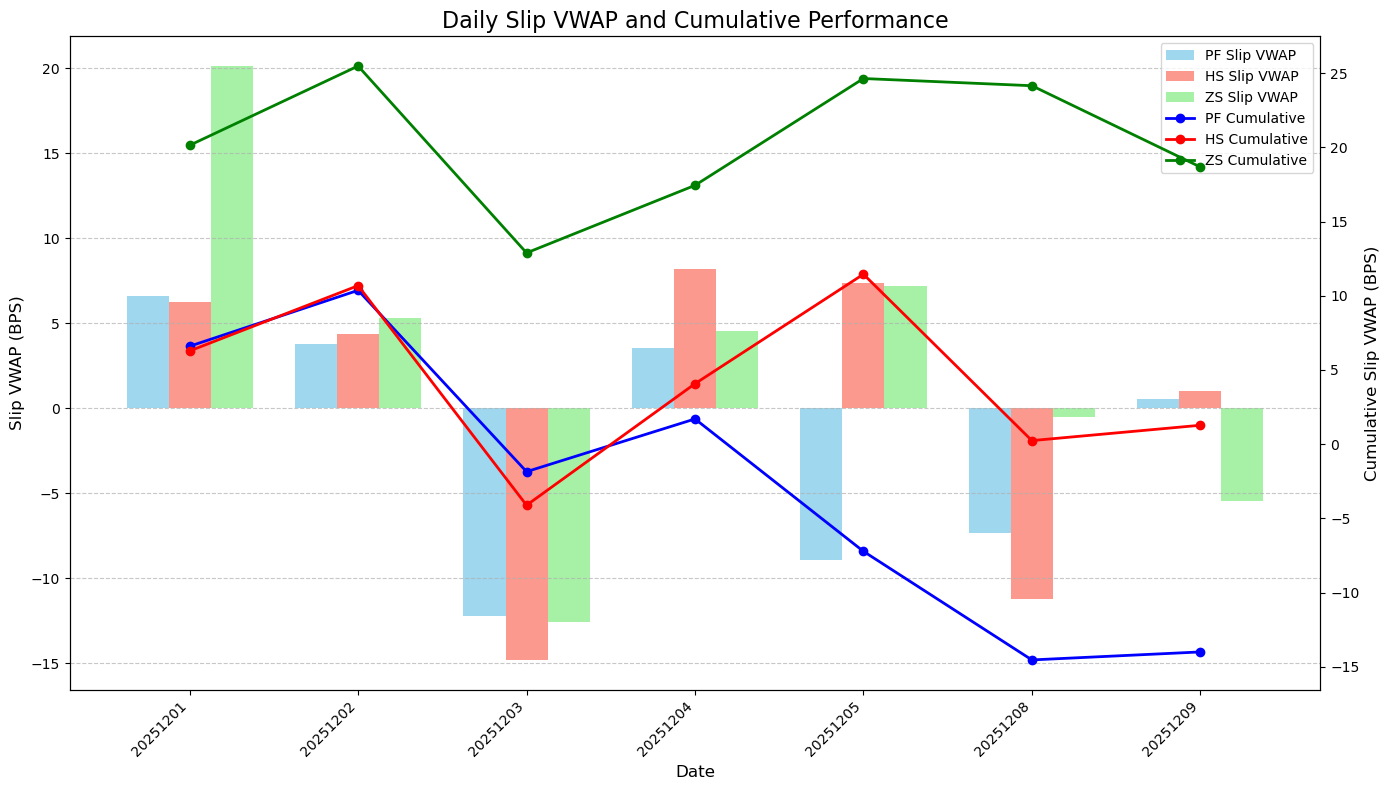

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# 确保在Jupyter notebook中显示图像
# %matplotlib inline

# 假设df已经包含date, pf_slipvwap, hs_slipvwap, zs_slipvwap列
# 如果date不是datetime格式，需要先转换
# if not np.issubdtype(df['date'].dtype, np.datetime64):
#     df['date'] = pd.to_datetime(df['date'])

# 计算累计值
df['PF_cum'] = df['PF_slipvwap'].cumsum()
df['HS_cum'] = df['HS_slipvwap'].cumsum()
df['ZS_cum'] = df['ZS_slipvwap'].cumsum()

# 设置图形大小
plt.figure(figsize=(14, 8))

# 创建主y轴用于柱状图
ax1 = plt.gca()

# 设置x轴位置
x = np.arange(len(df['date']))
width = 0.25  # 柱子的宽度

# 绘制三个柱状图，需要错开位置
ax1.bar(x - width, df['PF_slipvwap'], width, label='PF Slip VWAP', color='skyblue', alpha=0.8)
ax1.bar(x, df['HS_slipvwap'], width, label='HS Slip VWAP', color='salmon', alpha=0.8)
ax1.bar(x + width, df['ZS_slipvwap'], width, label='ZS Slip VWAP', color='lightgreen', alpha=0.8)

# 创建第二个y轴用于折线图
ax2 = ax1.twinx()

# 绘制累计折线图
ax2.plot(x, df['PF_cum'], 'o-', color='blue', linewidth=2, label='PF Cumulative')
ax2.plot(x, df['HS_cum'], 'o-', color='red', linewidth=2, label='HS Cumulative')
ax2.plot(x, df['ZS_cum'], 'o-', color='green', linewidth=2, label='ZS Cumulative')

# 设置x轴标签为日期
ax1.set_xticks(x)
ax1.set_xticklabels(df['date'], rotation=45, ha='right')

# 设置标题和标签
ax1.set_title('Daily Slip VWAP and Cumulative Performance', fontsize=16)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Slip VWAP (BPS)', fontsize=12)
ax2.set_ylabel('Cumulative Slip VWAP (BPS)', fontsize=12)

# 设置网格线
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=10)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

In [9]:
from dbfread import DBF

# 遍历文件中的每条记录
for record in DBF(r'C:\ATX\HTZQ-ATX\OrderScan\ReportPosition_20260313.dbf'):
    print(record)
# 输出示例: OrderedDict([('NAME', 'Alice'), ('BIRTHDATE', datetime.date(1987, 3, 1))])

OrderedDict([('ClientName', 'peibang-lr-71-hszx1'), ('Exchange', 1), ('Symbol', '300442.SZ'), ('CurrentQ', 600), ('EnableQty', 500), ('ShortQty', 0), ('UpdateTime', '20260313140533398')])
OrderedDict([('ClientName', 'peibang-lr-71-hszx1'), ('Exchange', 1), ('Symbol', '002138.SZ'), ('CurrentQ', 0), ('EnableQty', 0), ('ShortQty', 0), ('UpdateTime', '20260313140533398')])
OrderedDict([('ClientName', 'peibang-lr-71-hszx1'), ('Exchange', 2), ('Symbol', '600150.SH'), ('CurrentQ', 0), ('EnableQty', 0), ('ShortQty', 0), ('UpdateTime', '20260313140533398')])
OrderedDict([('ClientName', 'peibang-lr-71-hszx1'), ('Exchange', 2), ('Symbol', '600549.SH'), ('CurrentQ', 800), ('EnableQty', 700), ('ShortQty', 0), ('UpdateTime', '20260313140533398')])
OrderedDict([('ClientName', 'peibang-lr-71-hszx1'), ('Exchange', 2), ('Symbol', '601872.SH'), ('CurrentQ', 0), ('EnableQty', 0), ('ShortQty', 0), ('UpdateTime', '20260313140533398')])
OrderedDict([('ClientName', 'peibang-pt-71-pbzs'), ('Exchange', 2), ('Sy

In [14]:
date = '20260519'
uid = 'ABCD'

# 本地
data1 = pd.read_csv(rf'E:\code\generate_split_system\data\target\{date}\{date}_{uid}_000300.XSHG_zz1800_target.csv', index_col=0)
data2 = pd.read_csv(rf'E:\code\DailyScripts\TradeData\target\{date}\{date}_{uid}_000300.XSHG_zz1800_target.csv', index_col=0)

data = pd.merge(data1, data2, on='code', suffixes=('_local', '_remote'), how='outer')
data['diff'] = data['w_local'] - data['w_remote']

data


,code,w_local,w_remote,diff
0,000001.XSHE,0.006400,0.006400,0.0
1,000048.XSHE,0.002500,0.002500,0.0
2,000063.XSHE,0.007328,0.007328,0.0
3,000400.XSHE,0.002500,0.002500,0.0
4,000567.XSHE,0.002500,0.002500,0.0
...,...,...,...,...
214,688599.XSHG,0.002500,0.002500,0.0
215,688728.XSHG,0.002500,0.002500,0.0
216,688776.XSHG,0.002500,0.002500,0.0
217,688798.XSHG,0.002500,0.002500,0.0


In [15]:
data[data['diff'] != 0]

,code,w_local,w_remote,diff
25,002151.XSHE,0.000135,0.000135,5.200000e-10
66,300308.XSHE,0.020874,0.020874,7.600000e-08
126,600266.XSHG,0.000076,0.000077,-5.519850e-07
152,601066.XSHG,0.002278,0.002278,4.759000e-07
172,601698.XSHG,0.000717,0.000717,-5.200000e-10


In [16]:
data[data['code'] == '300308.XSHE']


,code,w_local,w_remote,diff
66,300308.XSHE,0.020874,0.020874,7.600000e-08


In [30]:
from ultis.FileTransfer import *

local_path = r'E:\code\generate_split_system\data\mo_order'
remote_path = '/home/zhanggh/DailyScripts/SplitSystemData/mo_order'

transfer = LinuxFileTransfer()
transfer.connect()

transfer.download_folder(remote_path, local_path)
transfer.disconnect()




SSH连接成功
  进入目录: /home/zhanggh/DailyScripts/SplitSystemData/mo_order/20250715
  进入目录: /home/zhanggh/DailyScripts/SplitSystemData/mo_order/20250716
  进入目录: /home/zhanggh/DailyScripts/SplitSystemData/mo_order/20250718
  下载: /home/zhanggh/DailyScripts/SplitSystemData/mo_order/20250718/20250718_gtja_PBPFZX1H_ATX_adj_KF_0935_0945_algo.csv -> E:\code\generate_split_system\data\mo_order\20250718\20250718_gtja_PBPFZX1H_ATX_adj_KF_0935_0945_algo.csv
  下载: /home/zhanggh/DailyScripts/SplitSystemData/mo_order/20250718/20250718_gtja_PBPFZX1H_ATX_t0_KF_0930_1455_algo.csv -> E:\code\generate_split_system\data\mo_order\20250718\20250718_gtja_PBPFZX1H_ATX_t0_KF_0930_1455_algo.csv
  下载: /home/zhanggh/DailyScripts/SplitSystemData/mo_order/20250718/20250718_haitong_PBPFZX1H_ATX_adj_KF_0935_0945_algo.csv -> E:\code\generate_split_system\data\mo_order\20250718\20250718_haitong_PBPFZX1H_ATX_adj_KF_0935_0945_algo.csv
  下载: /home/zhanggh/DailyScripts/SplitSystemData/mo_order/20250718/20250718_haitong_PBPFZX1H_A